In [2]:
work_dir = "/scratch/mjehangir/manuscript_figures/manuscript_data/"
setwd(work_dir)



In [3]:
library(ggpubr)
library(ggrepel)

In [4]:
library(ggplot2)

In [5]:
library(openxlsx)
library(dplyr)
library(tidyverse)
library(tidyr)
library(ggplot2)
library(pheatmap)
library(DescTools)
library(ggpubr)
library(DESeq2)
library(ComplexHeatmap)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.2.1
✔ purrr     1.0.4     ✔ tidyr     1.3.1
✔ readr     2.1.5     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.

In [6]:
# Step 1: Load the data from telomere data file
data <- read.csv("gliomas_telomers.csv")

# Step 2: Ensure 'chr_order' column is properly formatted and ordered
data$chr_order <- factor(data$chr_order, levels = c(1:22))

# Step 3: Combine 'chr_order' and 'arm' columns to get the full chromosome information
data$chr <- paste0("chr", data$chr_order, data$arm)

In [7]:
# Step 5: Characterize clinical samples based on telomere length
data$group <- ifelse(data$final_average_TL_p75 < 5000, "Short", "Normal")

# Step 6: Perform a t-test
t_test_result <- t.test(final_average_TL_p75 ~ group, data = data)

#  boxplot 
group_plot <- ggplot(data, aes(x = group, y = final_average_TL_p75, fill = group)) +
  geom_boxplot(width = 0.5, alpha = 0.5, outlier.shape = NA, color = "black", position = position_dodge(width = 0.75)) + # Adjust box width and position
  stat_summary(fun = median, geom = "point", shape = 18, size = 4, color = "darkblue") + # Median points
  geom_jitter(aes(color = group), width = 0.25, shape = 16, size = 2, alpha = 0.3) + # Jitter points
  labs(title = "Telomere Length Distribution for Clinical Samples (Short vs Normal)",
       x = "Group", y = "Telomere Length (p75)") +
  scale_fill_manual(values = c("Short" = "lightcoral", "Normal" = "lightblue")) + 
  scale_color_manual(values = c("Short" = "lightcoral", "Normal" = "lightblue")) +
  theme_minimal(base_size = 14) +  
  theme(legend.position = "none", 
        panel.grid.major = element_line(color = "grey90", size = 0.5),
        panel.grid.minor = element_blank(), # No minor grid lines
        axis.title = element_text(size = 16), 
        axis.text = element_text(size = 14),
        plot.title = element_text(size = 18, hjust = 0.5)) + 
  annotate("text", x = 1.5, y = max(data$final_average_TL_p75) * 0.95,
           label = paste("p =", signif(t_test_result$p.value, digits = 3)),
           size = 5, color = "black", fontface = "bold", hjust = 0.5) +  # Add p-value to the plot
  stat_compare_means(comparisons = list(c("Short", "Normal")), 
                    method = "t.test", 
                    label = "p.signif", 
                    size = 5, 
                    color = "black")  # Add significance annotation

Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


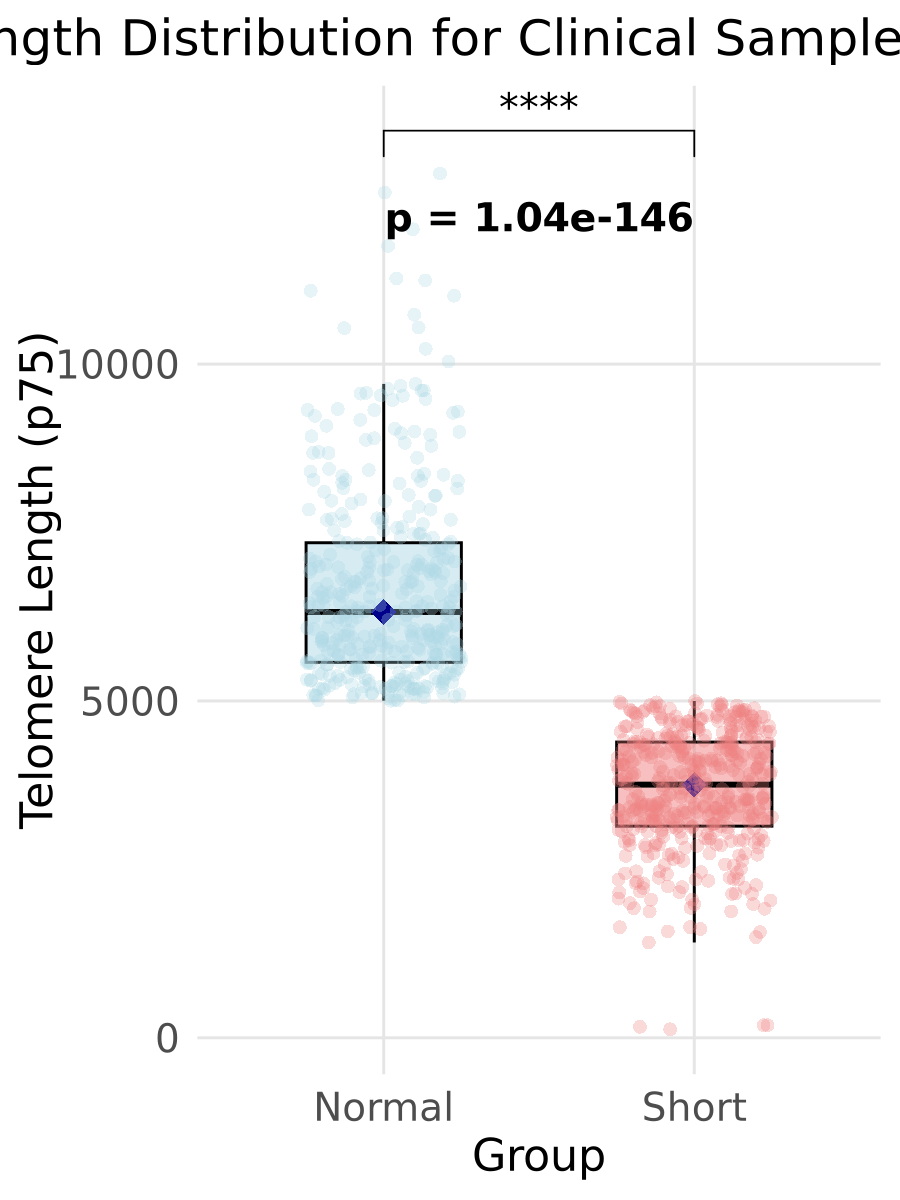

In [8]:
options(repr.plot.width = 4.5, repr.plot.height = 6, repr.plot.res = 200)
# Show the plot
print(group_plot)

In [9]:
pdf(file = "boxplot_normal_vs_short.pdf", width = 4.5, height = 6)
print(group_plot)
dev.off()

pdf 
  2

In [10]:
head(data)

,Sample_prefix,chr,final_average_TL_p75,chr_order,arm,group
,<chr>,<chr>,<dbl>,<fct>,<chr>,<chr>
1,2436A,chr1p,5221.000,1,p,Normal
2,2436A,chr1q,5051.167,1,q,Normal
3,3188,chr1p,1642.500,1,p,Short
4,3188,chr1q,3086.500,1,q,Short
5,3988,chr1p,2347.500,1,p,Short
6,3988,chr1q,5083.000,1,q,Normal


In [11]:

# Filter data for p and q arms
data_p <- data[data$arm == "p", ]
data_q <- data[data$arm == "q", ]


In [12]:
head(data_p)

,Sample_prefix,chr,final_average_TL_p75,chr_order,arm,group
,<chr>,<chr>,<dbl>,<fct>,<chr>,<chr>
1,2436A,chr1p,5221.0,1,p,Normal
3,3188,chr1p,1642.5,1,p,Short
5,3988,chr1p,2347.5,1,p,Short
7,6265D,chr1p,6548.0,1,p,Normal
9,6266D,chr1p,4224.0,1,p,Short
11,6269C,chr1p,4019.0,1,p,Short


In [13]:
# Custom sorting function for chromosome order
sort_chr <- function(chr_column, suffix) {
  chr_order <- as.numeric(gsub(paste0("chr|", suffix), "", chr_column))
  return(order(chr_order))
}

# Sort data for p arm
data_p <- data_p[sort_chr(data_p$chr, "p"), ]

# Sort data for q arm
data_q <- data_q[sort_chr(data_q$chr, "q"), ]



In [14]:
unique(data_p$chr)

[1] "chr1p"  "chr2p"  "chr3p"  "chr4p"  "chr5p"  "chr6p"  "chr7p"  "chr8p" 
 [9] "chr9p"  "chr10p" "chr11p" "chr12p" "chr13p" "chr14p" "chr15p" "chr16p"
[17] "chr17p" "chr18p" "chr19p" "chr20p" "chr21p" "chr22p"

In [15]:
# Ensure chr is a factor with the correct order
data_p$chr <- factor(data_p$chr, levels = paste0("chr", 1:22, "p"))
data_q$chr <- factor(data_q$chr, levels = paste0("chr", 1:22, "q"))



In [16]:
p_p <- ggplot(data_p, aes(x = chr, y = final_average_TL_p75, fill = arm)) +
  geom_violin(trim = FALSE, alpha = 0.3) +
  geom_boxplot(width = 0.25, outlier.size = 0.5, position = position_dodge(0.9), fill = "white") +  # White boxplot
  geom_jitter(width = 0.2, size = 1.5, alpha = 1, color = "skyblue4") +
  geom_hline(yintercept = mean(data_p$final_average_TL_p75), linetype = "dashed", color = "red", linewidth = 0.8) +
  labs(
    x = "Chromosomes",
    y = "Telomere Length",
    title = "Distribution of Telomere Lengths (p arm)"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  scale_fill_manual(values = c("p" = "skyblue"))

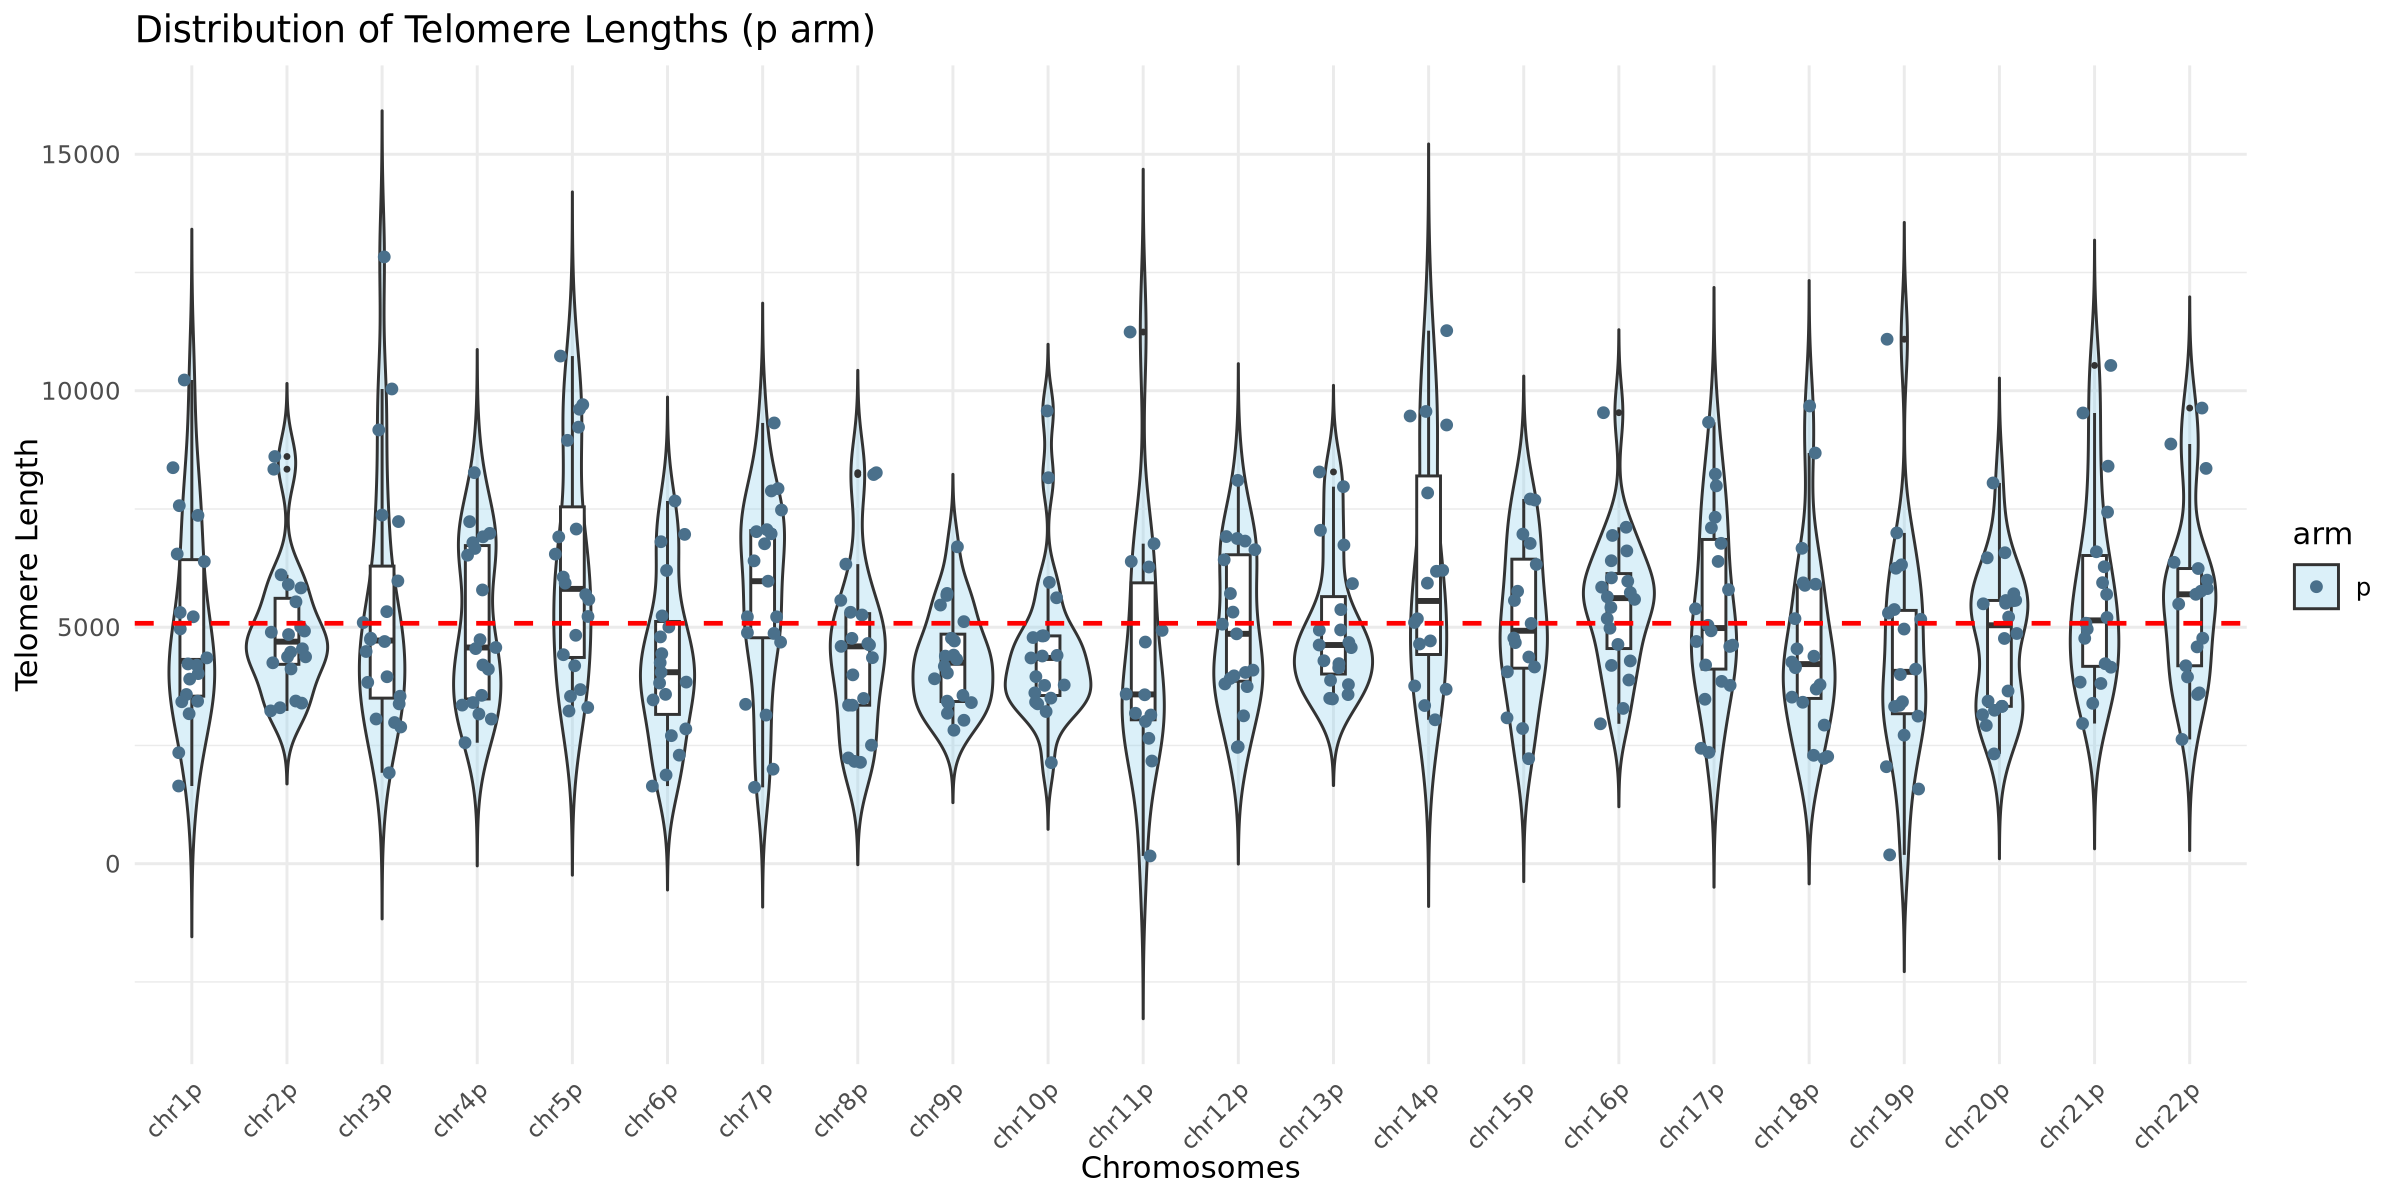

In [17]:
options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 200)
print(p_p)


In [18]:
pdf(file = "violinplot_chromosome_telo_length_Parm.pdf", width = 12, height = 6)
print(p_p)
dev.off()

pdf 
  2

In [19]:
p_q <- ggplot(data_q, aes(x = chr, y = final_average_TL_p75, fill = arm)) +
  geom_violin(trim = FALSE, alpha = 0.5) +
  geom_boxplot(width = 0.25, outlier.size = 0.5, position = position_dodge(0.9), fill = "white") +  # White boxplot
  geom_jitter(width = 0.2, size = 1, alpha = 1, color = "purple2") +
  geom_hline(yintercept = mean(data_p$final_average_TL_p75), linetype = "dashed", color = "red", linewidth = 0.8) +
  labs(
    x = "Chromosomes",
    y = "Telomere Length",
    title = "Distribution of Telomere Lengths (q arm)"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  scale_fill_manual(values = c("q" = "purple4"))

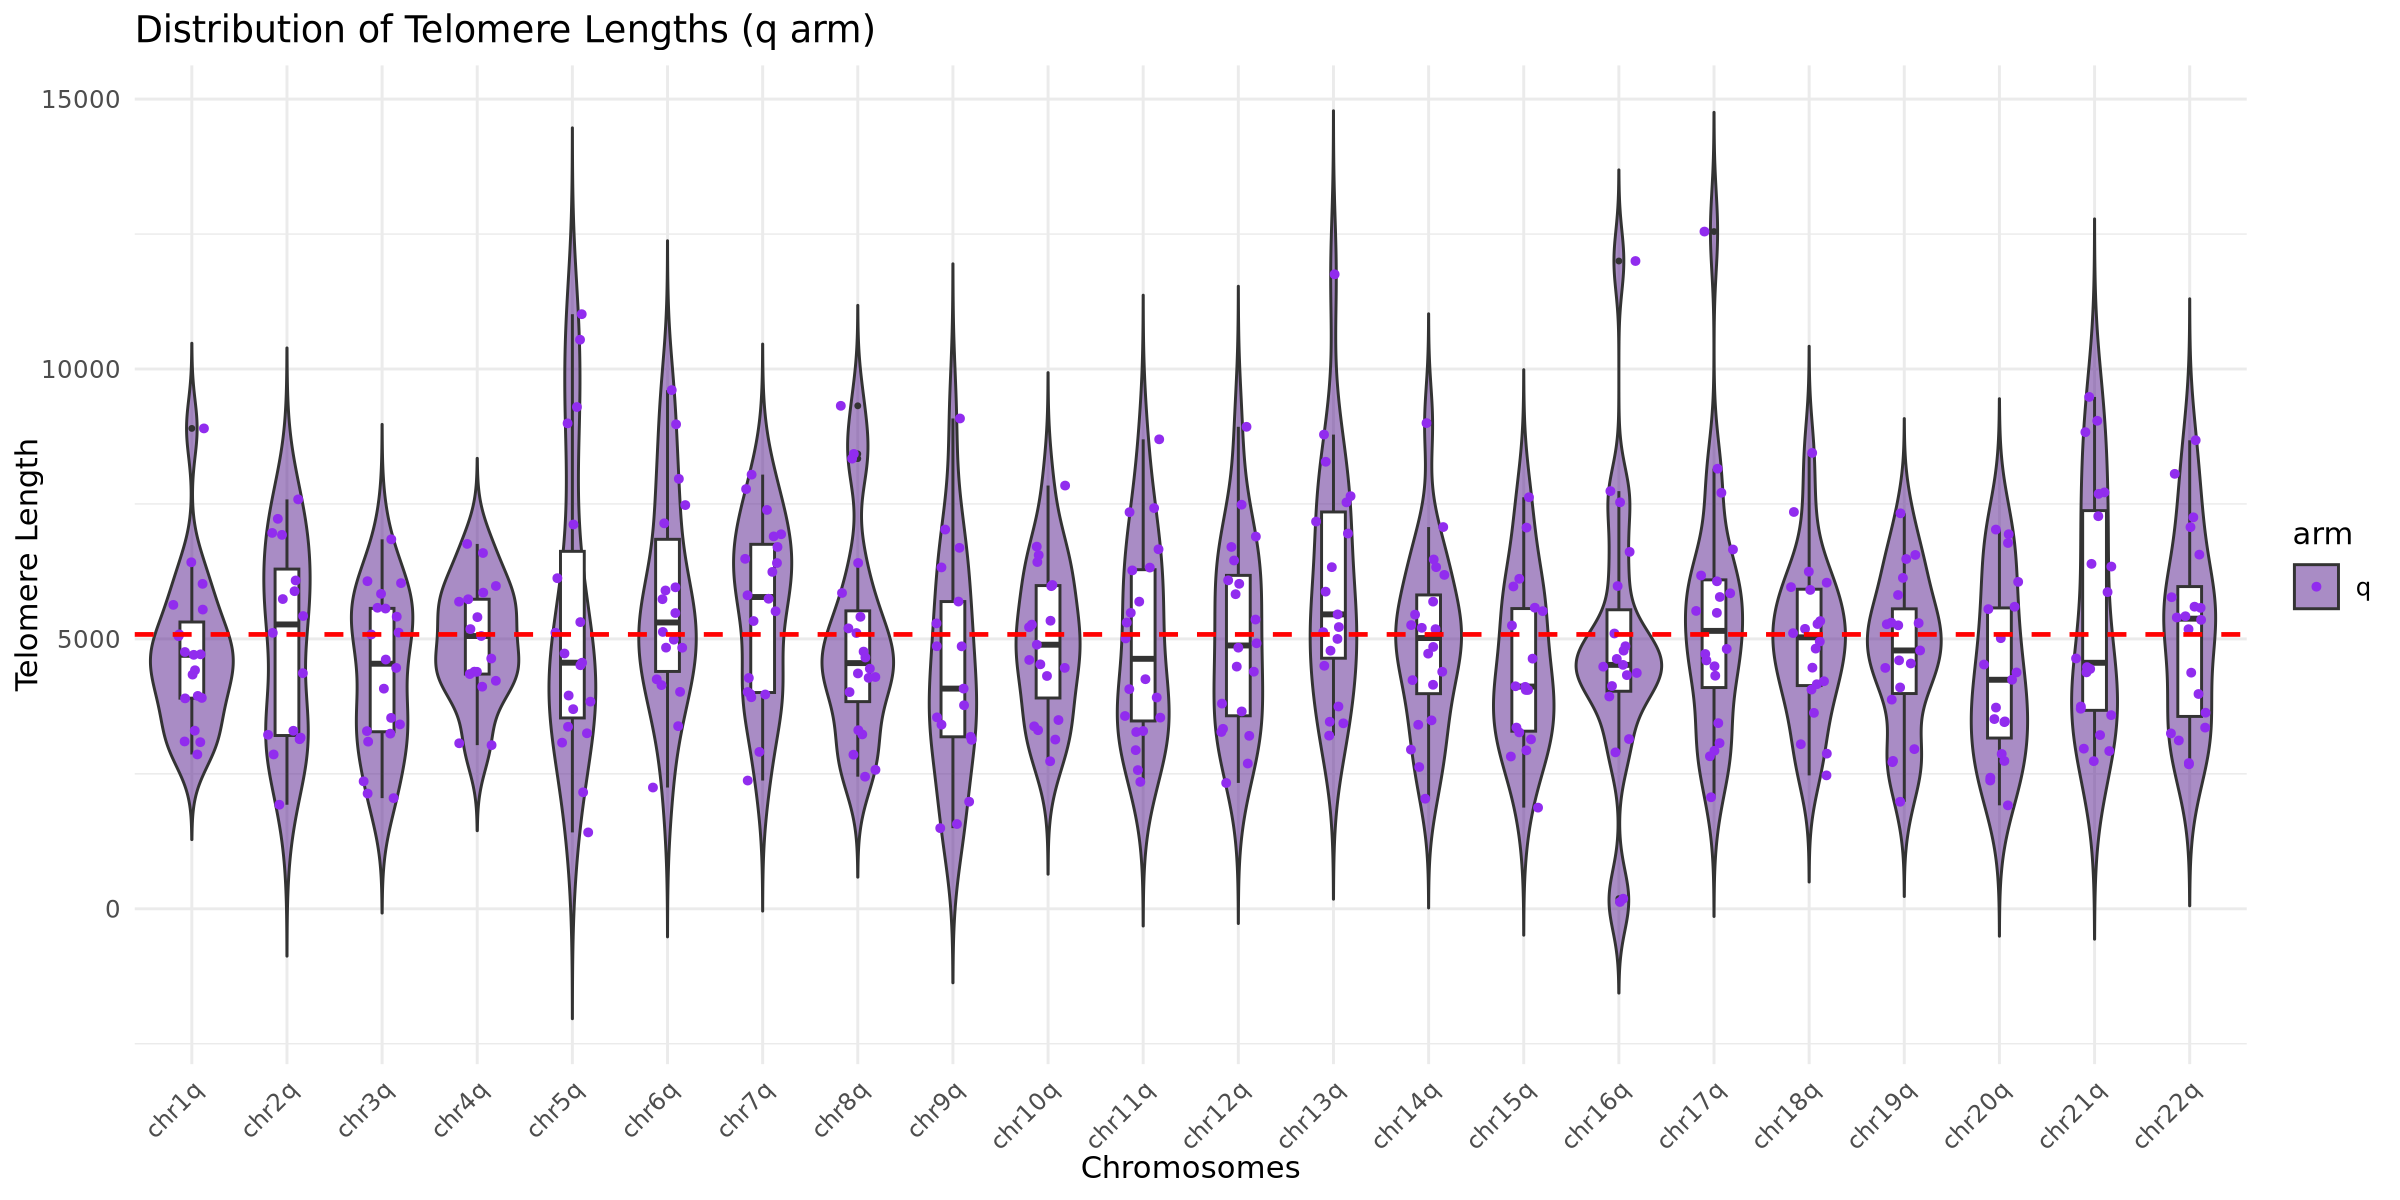

In [20]:
print(p_q)

In [21]:
pdf(file = "violinplot_chromosome_telo_length_Qarm.pdf", width = 12, height = 6)
print(p_q)
dev.off()

pdf 
  2

In [22]:
#Distribution of telomere length by density

density_plot <- ggplot(data, aes(x = final_average_TL_p75, fill = group)) +
  geom_density(alpha = 0.4) +
  labs(title = "Density Plot of Telomere Lengths",
       x = "Telomere Length (p75)",
       y = "Density") +
  scale_fill_manual(values = c("Short" = "lightcoral", "Normal" = "lightblue")) +
  theme_minimal()


In [23]:
head(data)

,Sample_prefix,chr,final_average_TL_p75,chr_order,arm,group
,<chr>,<chr>,<dbl>,<fct>,<chr>,<chr>
1,2436A,chr1p,5221.000,1,p,Normal
2,2436A,chr1q,5051.167,1,q,Normal
3,3188,chr1p,1642.500,1,p,Short
4,3188,chr1q,3086.500,1,q,Short
5,3988,chr1p,2347.500,1,p,Short
6,3988,chr1q,5083.000,1,q,Normal


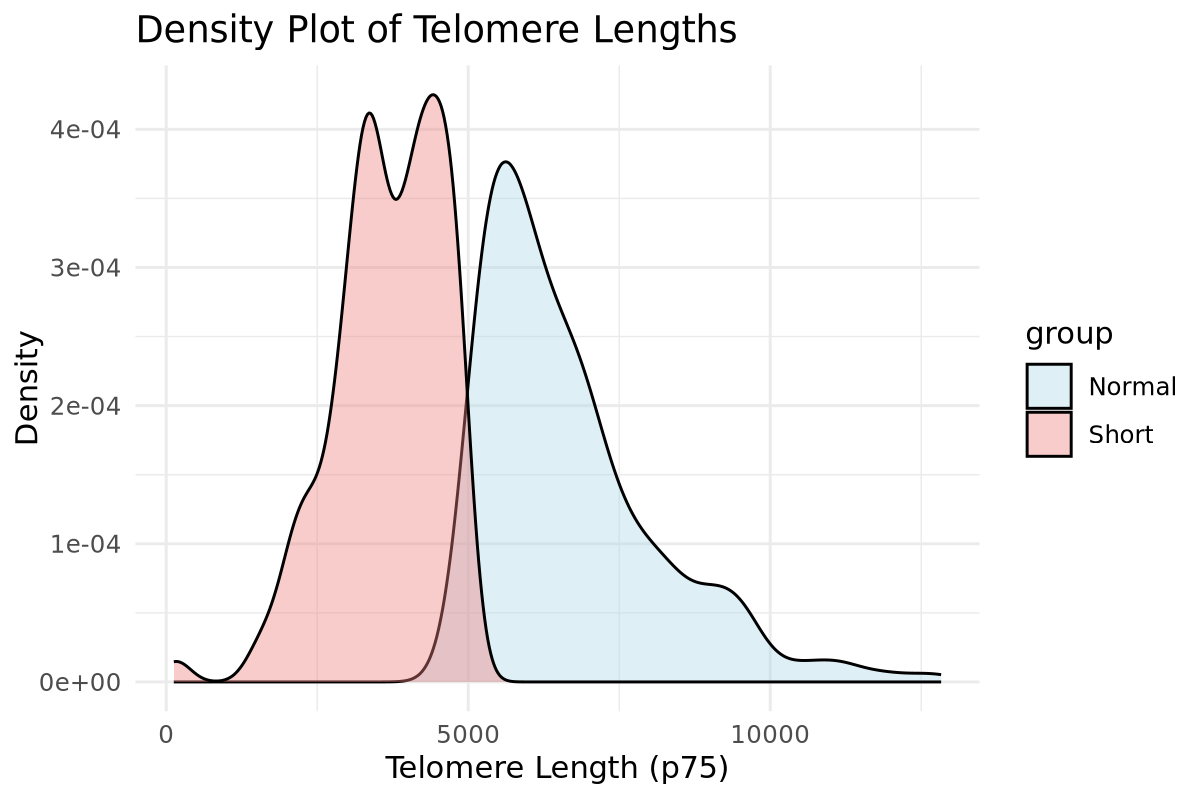

In [24]:
options(repr.plot.width = 6, repr.plot.height = 4, repr.plot.res = 200)
print(density_plot)

In [25]:
pdf(file = "density_plot_telo_length_distribution.pdf", width = 6, height = 4)
print(density_plot)
dev.off()

pdf 
  2

In [26]:
#Heatmap Figure for relative telomere length
# Load the data
data <- read.csv("gliomas_telomers.csv")

# Calculate relative telomere length in kilobases (already done earlier)
data$grand_mean_TL <- ave(data$final_average_TL_p75, data$Sample_prefix, FUN = mean)
data$relative_TL <- (data$final_average_TL_p75 - data$grand_mean_TL) / 1000  # Convert to kb

# Reshape the data for the heatmap (ensure chr is included in the reshaped data)
data_heatmap <- data %>%
  select(Sample_prefix, chr, relative_TL) %>%
  spread(key = chr, value = relative_TL)  # organize chromosomes into separate columns


In [27]:
# Check the reshaped data (optional for debugging)
head(data_heatmap)

,Sample_prefix,chr10p,chr10q,chr11p,chr11q,chr12p,chr12q,chr13p,chr13q,chr14p,⋯,chr5p,chr5q,chr6p,chr6q,chr7p,chr7q,chr8p,chr8q,chr9p,chr9q
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2436A,-1.9249077,-2.8039077,1.2293423,-0.2336577,-0.2172577,0.54834230,2.435628,-0.0826577,4.0253423,⋯,1.00909230,5.0055506,-1.48815770,0.3602709,-0.8523244,0.9464256,-0.7719077,0.8696756,-1.14707436,-1.9904077
2,3188,-0.6548177,0.7056823,-0.1395677,0.5021823,-0.3173177,-0.09981766,1.439682,0.6741823,NA,⋯,0.89018234,-0.6328177,-0.08331766,-0.5444843,-1.1758177,-0.4150677,-0.5541927,0.5168490,0.03168234,0.3388823
3,3988,-1.8609273,0.3678227,-2.0436773,-0.6223440,2.4743227,-1.23817732,2.652323,0.2446560,-0.4524273,⋯,0.05798934,0.4939893,-2.78042732,NA,-0.4106773,-0.2996773,-1.0061773,-0.9756773,1.06965601,3.4528227
4,6265D,-1.2326736,-1.4409236,-1.1176736,-1.9816736,0.8663264,1.43532639,-2.264174,5.7033264,1.7888264,⋯,1.02532639,NA,1.61857639,2.9243264,-0.8314236,1.7248264,-1.6940903,2.2888264,-2.64400694,0.6363264
5,6266D,0.4971745,-0.2348255,-0.7645755,0.8181745,-1.3583255,-3.11982554,1.599174,2.0788411,-1.7620755,⋯,-1.26532554,-2.0788255,-0.65545054,-2.0673255,-0.5808255,0.7901745,-3.3073255,-1.1728255,-1.04032554,-0.5888255
6,6269C,-1.0871191,1.5578809,NA,-0.9516191,-0.8224524,0.05313089,1.056381,0.3533809,0.2343809,⋯,1.06688089,-1.7876191,2.09738089,NA,2.6123809,-0.8496191,-0.2701191,-0.5721191,-0.95561911,0.8260059


In [28]:

# Plot the relative telomere length of all chromosomes 

# Load required libraries
library(ggplot2)
library(dplyr)
library(gridExtra) # For combining plots



Attaching package: ‘gridExtra’


The following object is masked from ‘package:Biobase’:

    combine


The following object is masked from ‘package:BiocGenerics’:

    combine


The following object is masked from ‘package:dplyr’:

    combine




In [29]:
# Load the data
data <- read.csv("gliomas_telomers.csv")


In [30]:
# Calculate grand mean and relative telomere length in kilobases
data$grand_mean_TL <- ave(data$final_average_TL_p75, data$Sample_prefix, FUN = mean)
data$relative_TL <- (data$final_average_TL_p75 - data$grand_mean_TL) / 1000  # Convert to kb
# Order chromosomes by shortest average telomere length
chr_order <- data %>%
  group_by(chr) %>%
  summarise(mean_TL = mean(final_average_TL_p75)) %>%
  arrange(mean_TL) %>%
  pull(chr)
data$chr <- factor(data$chr, levels = chr_order)

# Calculate the overall grand mean (dotted line in the plot)
overall_grand_mean <- mean(data$relative_TL)


In [31]:
# Separate p and q arms
data_p <- data %>% filter(arm == "p")
data_q <- data %>% filter(arm == "q")

# Define publication-quality colors
fill_p_color <- "#6a4c92"  # Soft purple for p arm
fill_q_color <- "#4c8c99"  # Soft blue for q arm
boxplot_color <- "black"
line_color <- "darkred"

In [32]:

# Plot for p arms 
plot_p <- ggplot(data_p, aes(x = chr, y = relative_TL)) +
  geom_violin(alpha = 0.4, fill = fill_p_color, color = NA, show.legend = FALSE) +
  geom_boxplot(width = 0.2, fill = "white", outlier.shape = NA, color = boxplot_color, show.legend = FALSE) +
  stat_summary(fun = mean, geom = "line", aes(group = 1), color = line_color, linewidth = 1, show.legend = FALSE) +  # Replaced 'size' with 'linewidth'
  geom_hline(yintercept = overall_grand_mean, linetype = "dotted", color = "black", linewidth = 1) +  # Replaced 'size' with 'linewidth'
  labs(
    title = "Relative Telomere Length for p Arms",
    x = "Chromosome Arm",
    y = "Relative Telomere Length (kb)"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))





# Plot for q arms 
plot_q <- ggplot(data_q, aes(x = chr, y = relative_TL)) +
  geom_violin(alpha = 0.4, fill = fill_q_color, color = NA, show.legend = FALSE) +
  geom_boxplot(width = 0.2, fill = "white", outlier.shape = NA, color = boxplot_color, show.legend = FALSE) +
  stat_summary(fun = mean, geom = "line", aes(group = 1), color = line_color, linewidth = 1, show.legend = FALSE) +  # Replaced 'size' with 'linewidth'
  geom_hline(yintercept = overall_grand_mean, linetype = "dotted", color = "black", linewidth = 1) +  # Replaced 'size' with 'linewidth'
  labs(
    title = "Relative Telomere Length for q Arms",
    x = "Chromosome Arm",
    y = "Relative Telomere Length (kb)"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Combine the plots using gridExtra with a more professional look
#grid.arrange(plot_p, plot_q, ncol = 1, heights = c(3, 3))
#options(repr.plot.width = 8, repr.plot.height = 10, repr.plot.res = 200)
#print(plot_p, plot_q)


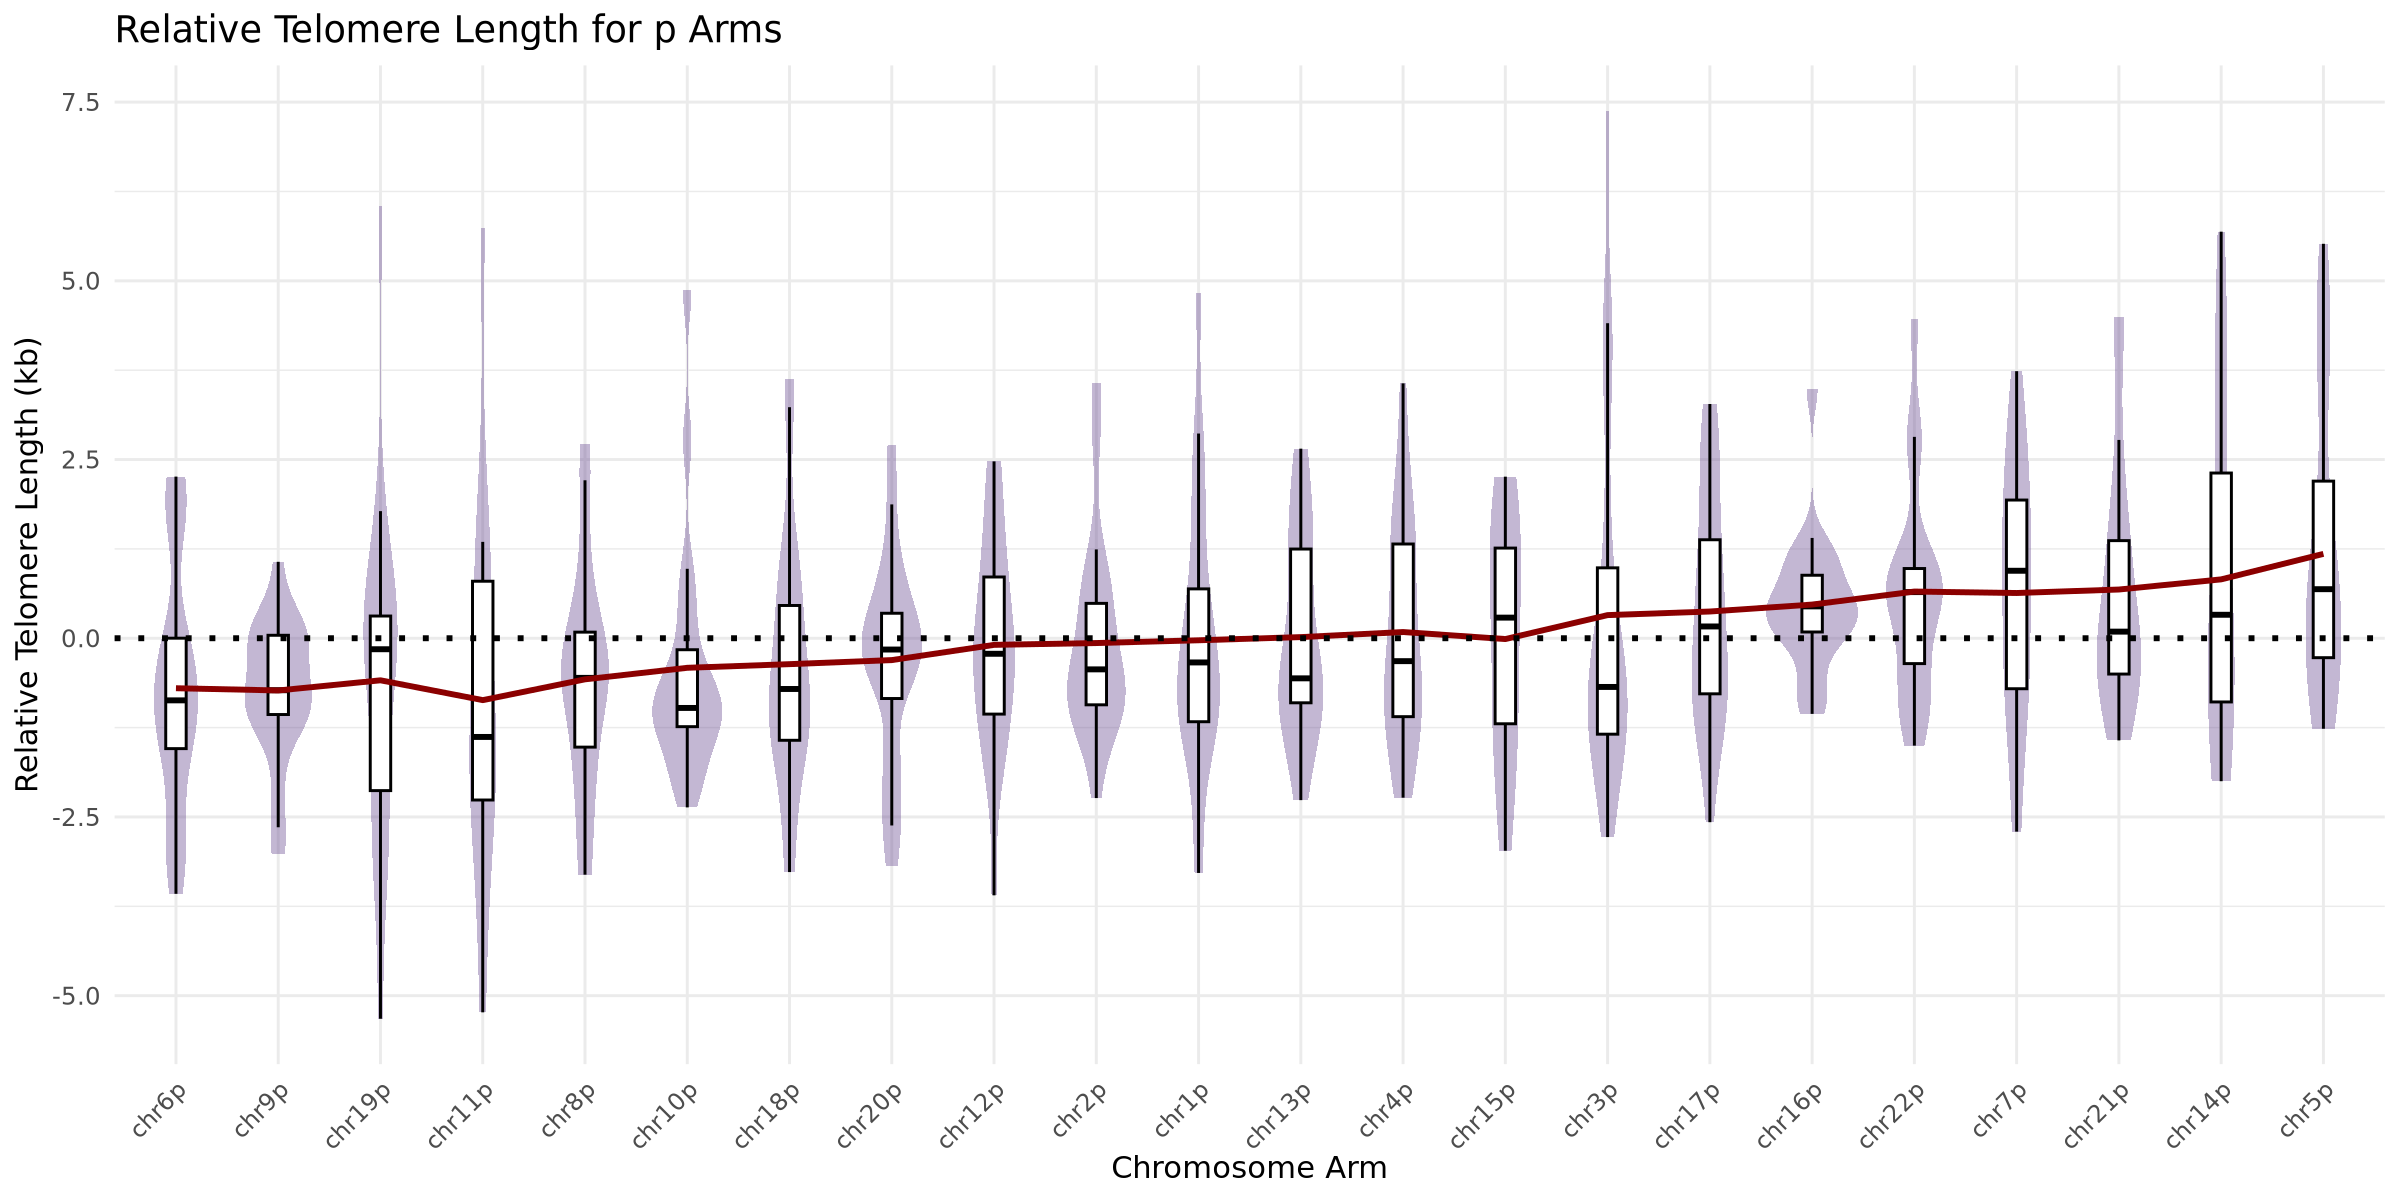

In [33]:
options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 200)
print(plot_p)

In [34]:
pdf(file = "Relative_length_violinplot_chromosome_P_arm.pdf", width = 12, height = 6)
print(plot_p)
dev.off()

pdf 
  2

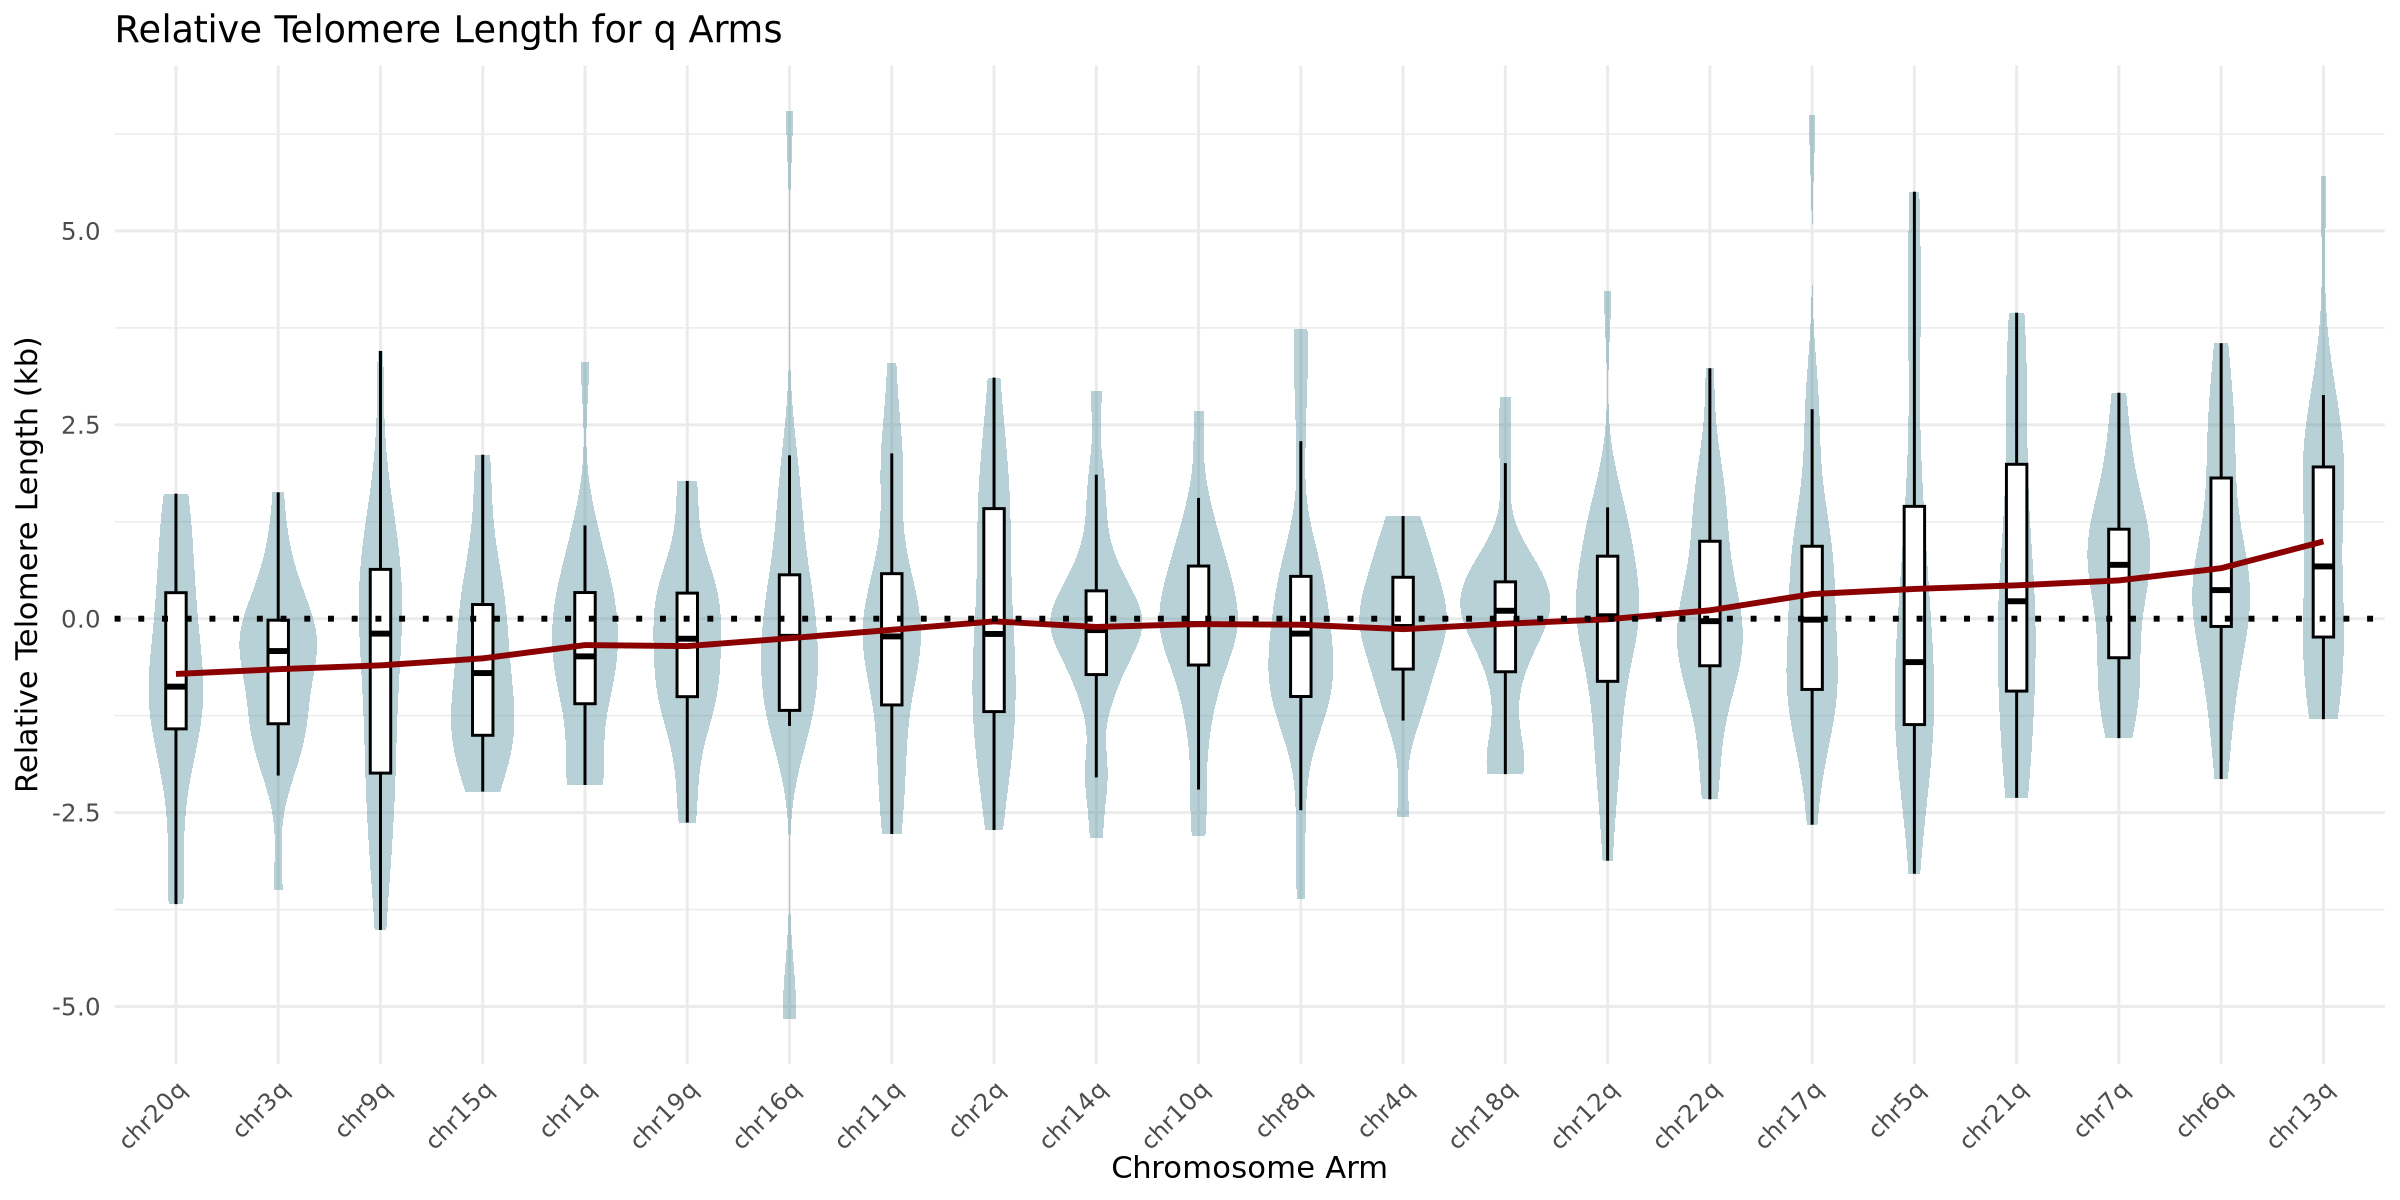

In [35]:
options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 200)
print(plot_q)

In [36]:
pdf(file = "Relative_length_violinplot_chromosome_q_arm.pdf", width = 12, height = 6)
print(plot_q)
dev.off()

pdf 
  2

In [37]:
head(data)

,Sample_prefix,chr,final_average_TL_p75,chr_order,arm,grand_mean_TL,relative_TL
,<chr>,<fct>,<dbl>,<int>,<chr>,<dbl>,<dbl>
1,2436A,chr1p,5221.000,1,p,5536.658,-0.3156577
2,2436A,chr1q,5051.167,1,q,5536.658,-0.4854910
3,3188,chr1p,1642.500,1,p,2790.818,-1.1483177
4,3188,chr1q,3086.500,1,q,2790.818,0.2956823
5,3988,chr1p,2347.500,1,p,5630.677,-3.2831773
6,3988,chr1q,5083.000,1,q,5630.677,-0.5476773


In [ ]:
library(ggplot2)
library(dplyr)

# Make sure chr is a factor ordered by chromosome number and arm
data <- data %>%
  mutate(
    chr = factor(chr, levels = paste0("chr", rep(1:22, each = 2), c("p", "q")))
  )

# Create a new column for arm color
data <- data %>%
  mutate(
    arm_color = ifelse(arm == "p", "mediumpurple4", "brown")
  )

# Calculate overall mean relative TL (optional, you can remove geom_hline if not needed)
overall_grand_mean <- mean(data$relative_TL, na.rm = TRUE)

pdf("/home/mjehangir/glioma_manuscript/fig2/telomers_per_chr.pdf", width = 12, height = 6)
ggplot(data, aes(x = chr, y = relative_TL, fill = arm_color)) +
  geom_violin(alpha = 0.6, color = NA, show.legend = FALSE) + 
  geom_boxplot(width = 0.2, fill = "white", outlier.shape = NA, color = "black", show.legend = FALSE) +
  geom_hline(yintercept = overall_grand_mean, linetype = "dotted", color = "darkgrey", linewidth = 1) +
  scale_fill_identity() +  # Use the colors as is from arm_color column
  labs(
    title = "Relative Telomere Length by Chromosome Arm",
    x = "Chromosome Arm",
    y = "Relative Telomere Length (kb)"
  ) +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))
dev.off()

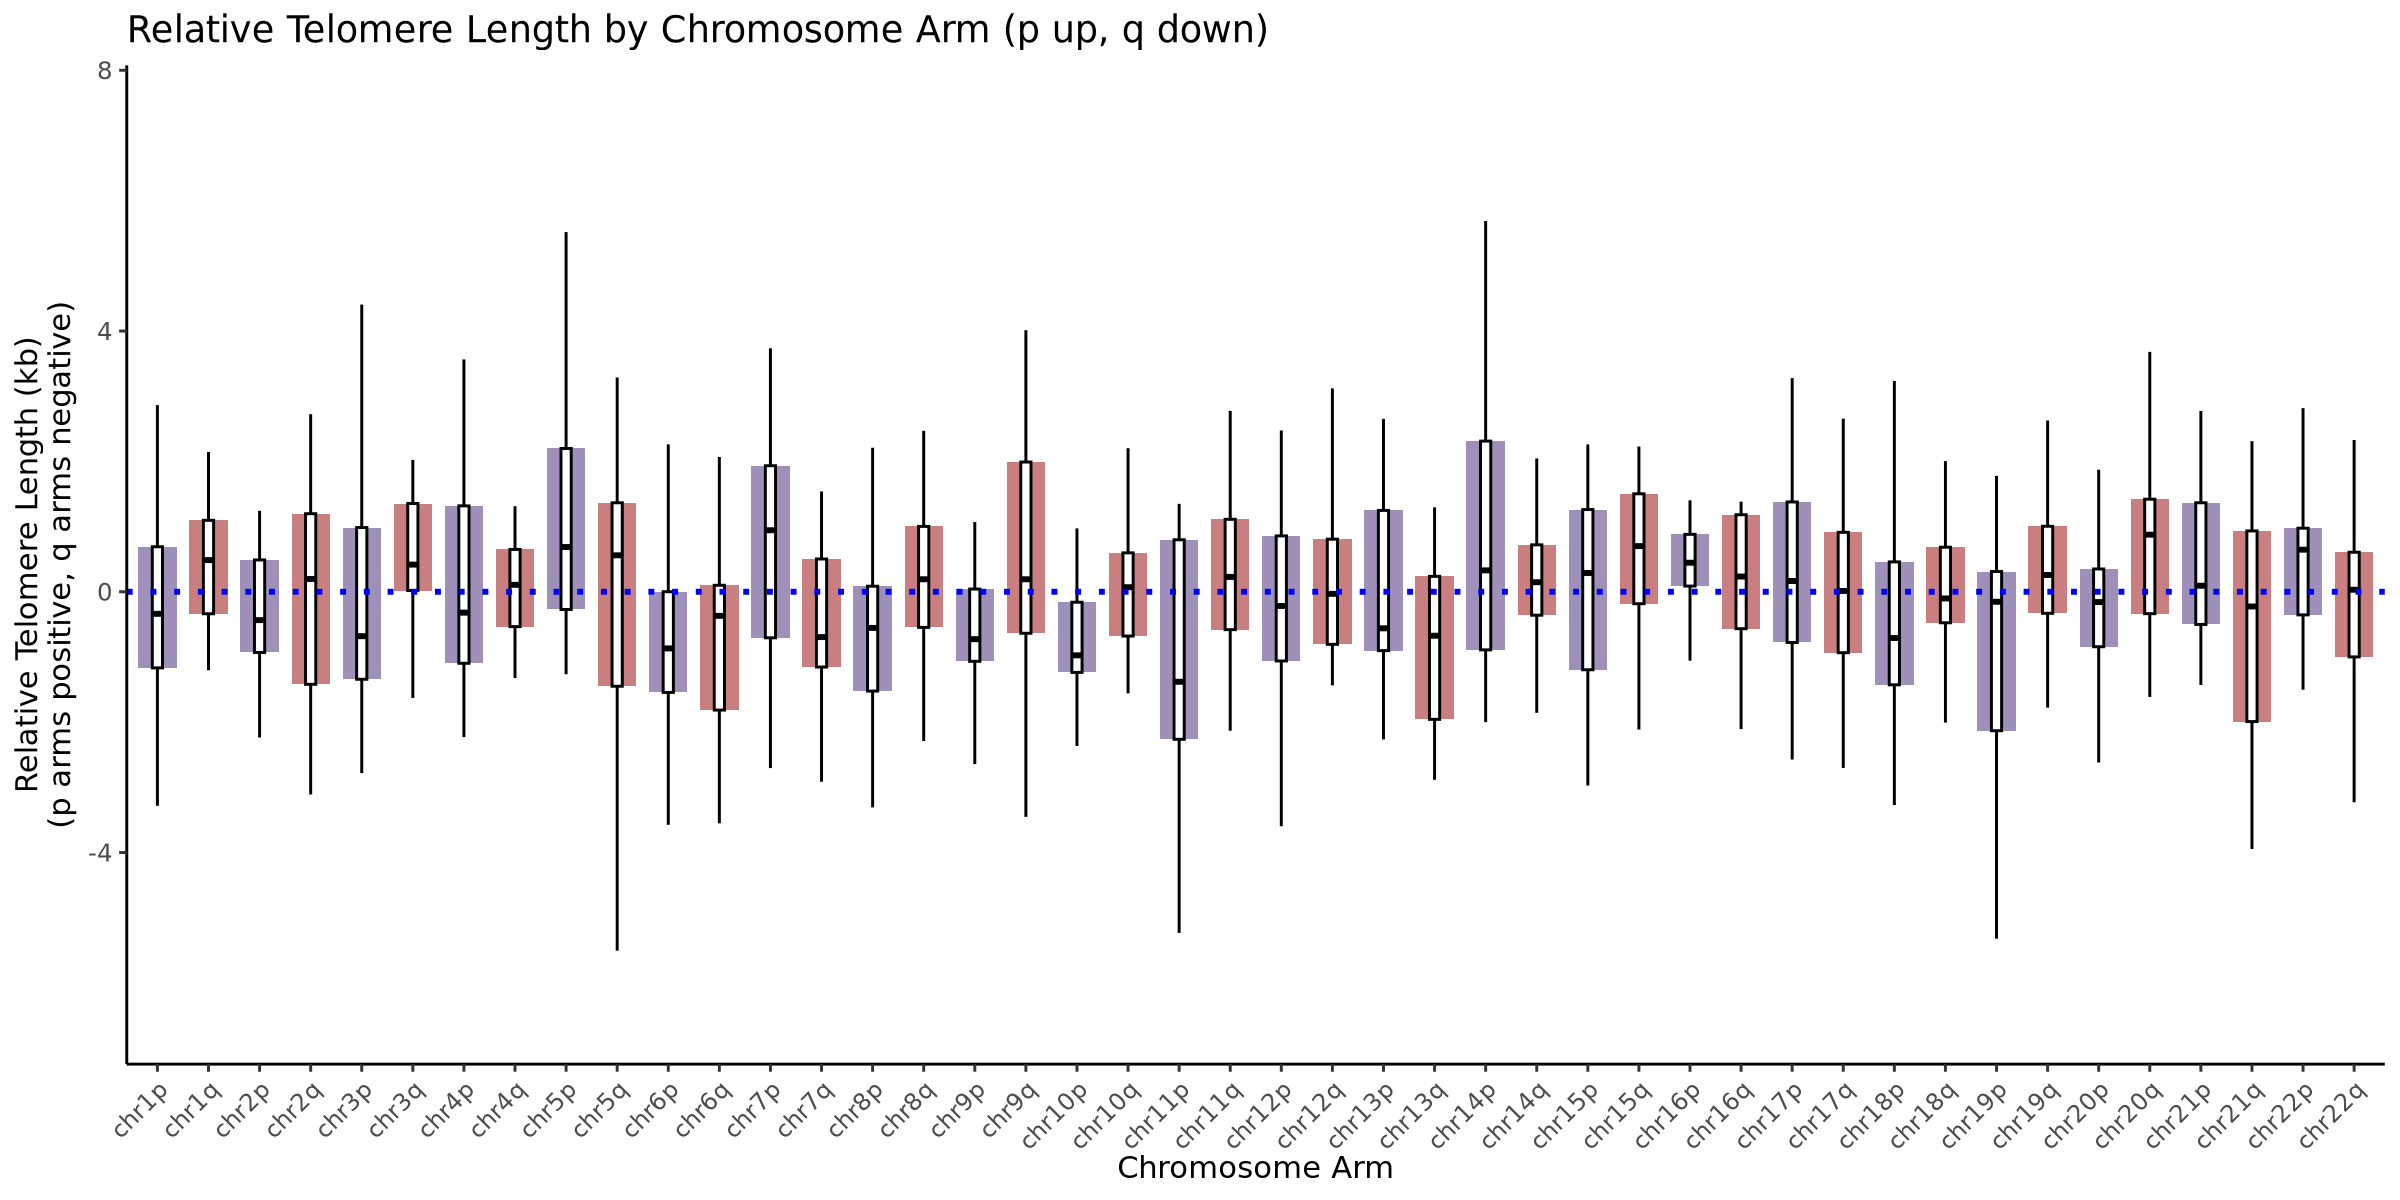

In [75]:
library(ggplot2)
library(dplyr)

# Create a new column that inverts q arm values to negative
data <- data %>%
  mutate(
    arm = ifelse(grepl("p$", chr), "p", "q"),
    plot_TL = ifelse(arm == "q", -relative_TL, relative_TL)
  )

ggplot(data, aes(x = chr, y = plot_TL, fill = arm_color)) +
  geom_boxplot(alpha = 0.6, color = NA, show.legend = FALSE) +
  geom_boxplot(width = 0.2, fill = "white", outlier.shape = NA, color = "black", show.legend = FALSE) +
  geom_hline(yintercept = 0, linetype = "dotted", color = "blue", linewidth = 1) +
  scale_fill_identity() +
  labs(
    title = "Relative Telomere Length by Chromosome Arm (p up, q down)",
    x = "Chromosome Arm",
    y = "Relative Telomere Length (kb)\n(p arms positive, q arms negative)"
  ) +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


In [74]:
# Add the Category column based on telomere length
data <- data %>%
  mutate(Category = ifelse(final_average_TL_p75 < 5000, "Short", "Normal"))


# Count the number of samples per Category for each Chromosome arm
data_count <- data %>%
  group_by(arm, Category, chr) %>%
  summarise(count = n())



`summarise()` has grouped output by 'arm', 'Category'. You can override using
the `.groups` argument.


In [75]:

# Create bar plot to compare each telomere short vs normal by samples count
p <- ggplot(data_count, aes(x = arm, y = count, fill = Category)) +
  geom_bar(stat = "identity", position = "dodge", alpha = 0.7) +
  scale_fill_manual(values = c("Short" = "lightcoral", "Normal" = "lightblue")) +
  labs(
    title = "Number of Samples by Telomere Category and Chromosome Arm",
    x = "Chromosome Arm",
    y = "Number of Samples",
    fill = "Telomere Category"
  ) +
  facet_wrap(~ chr, scales = "free") +
  theme_minimal()



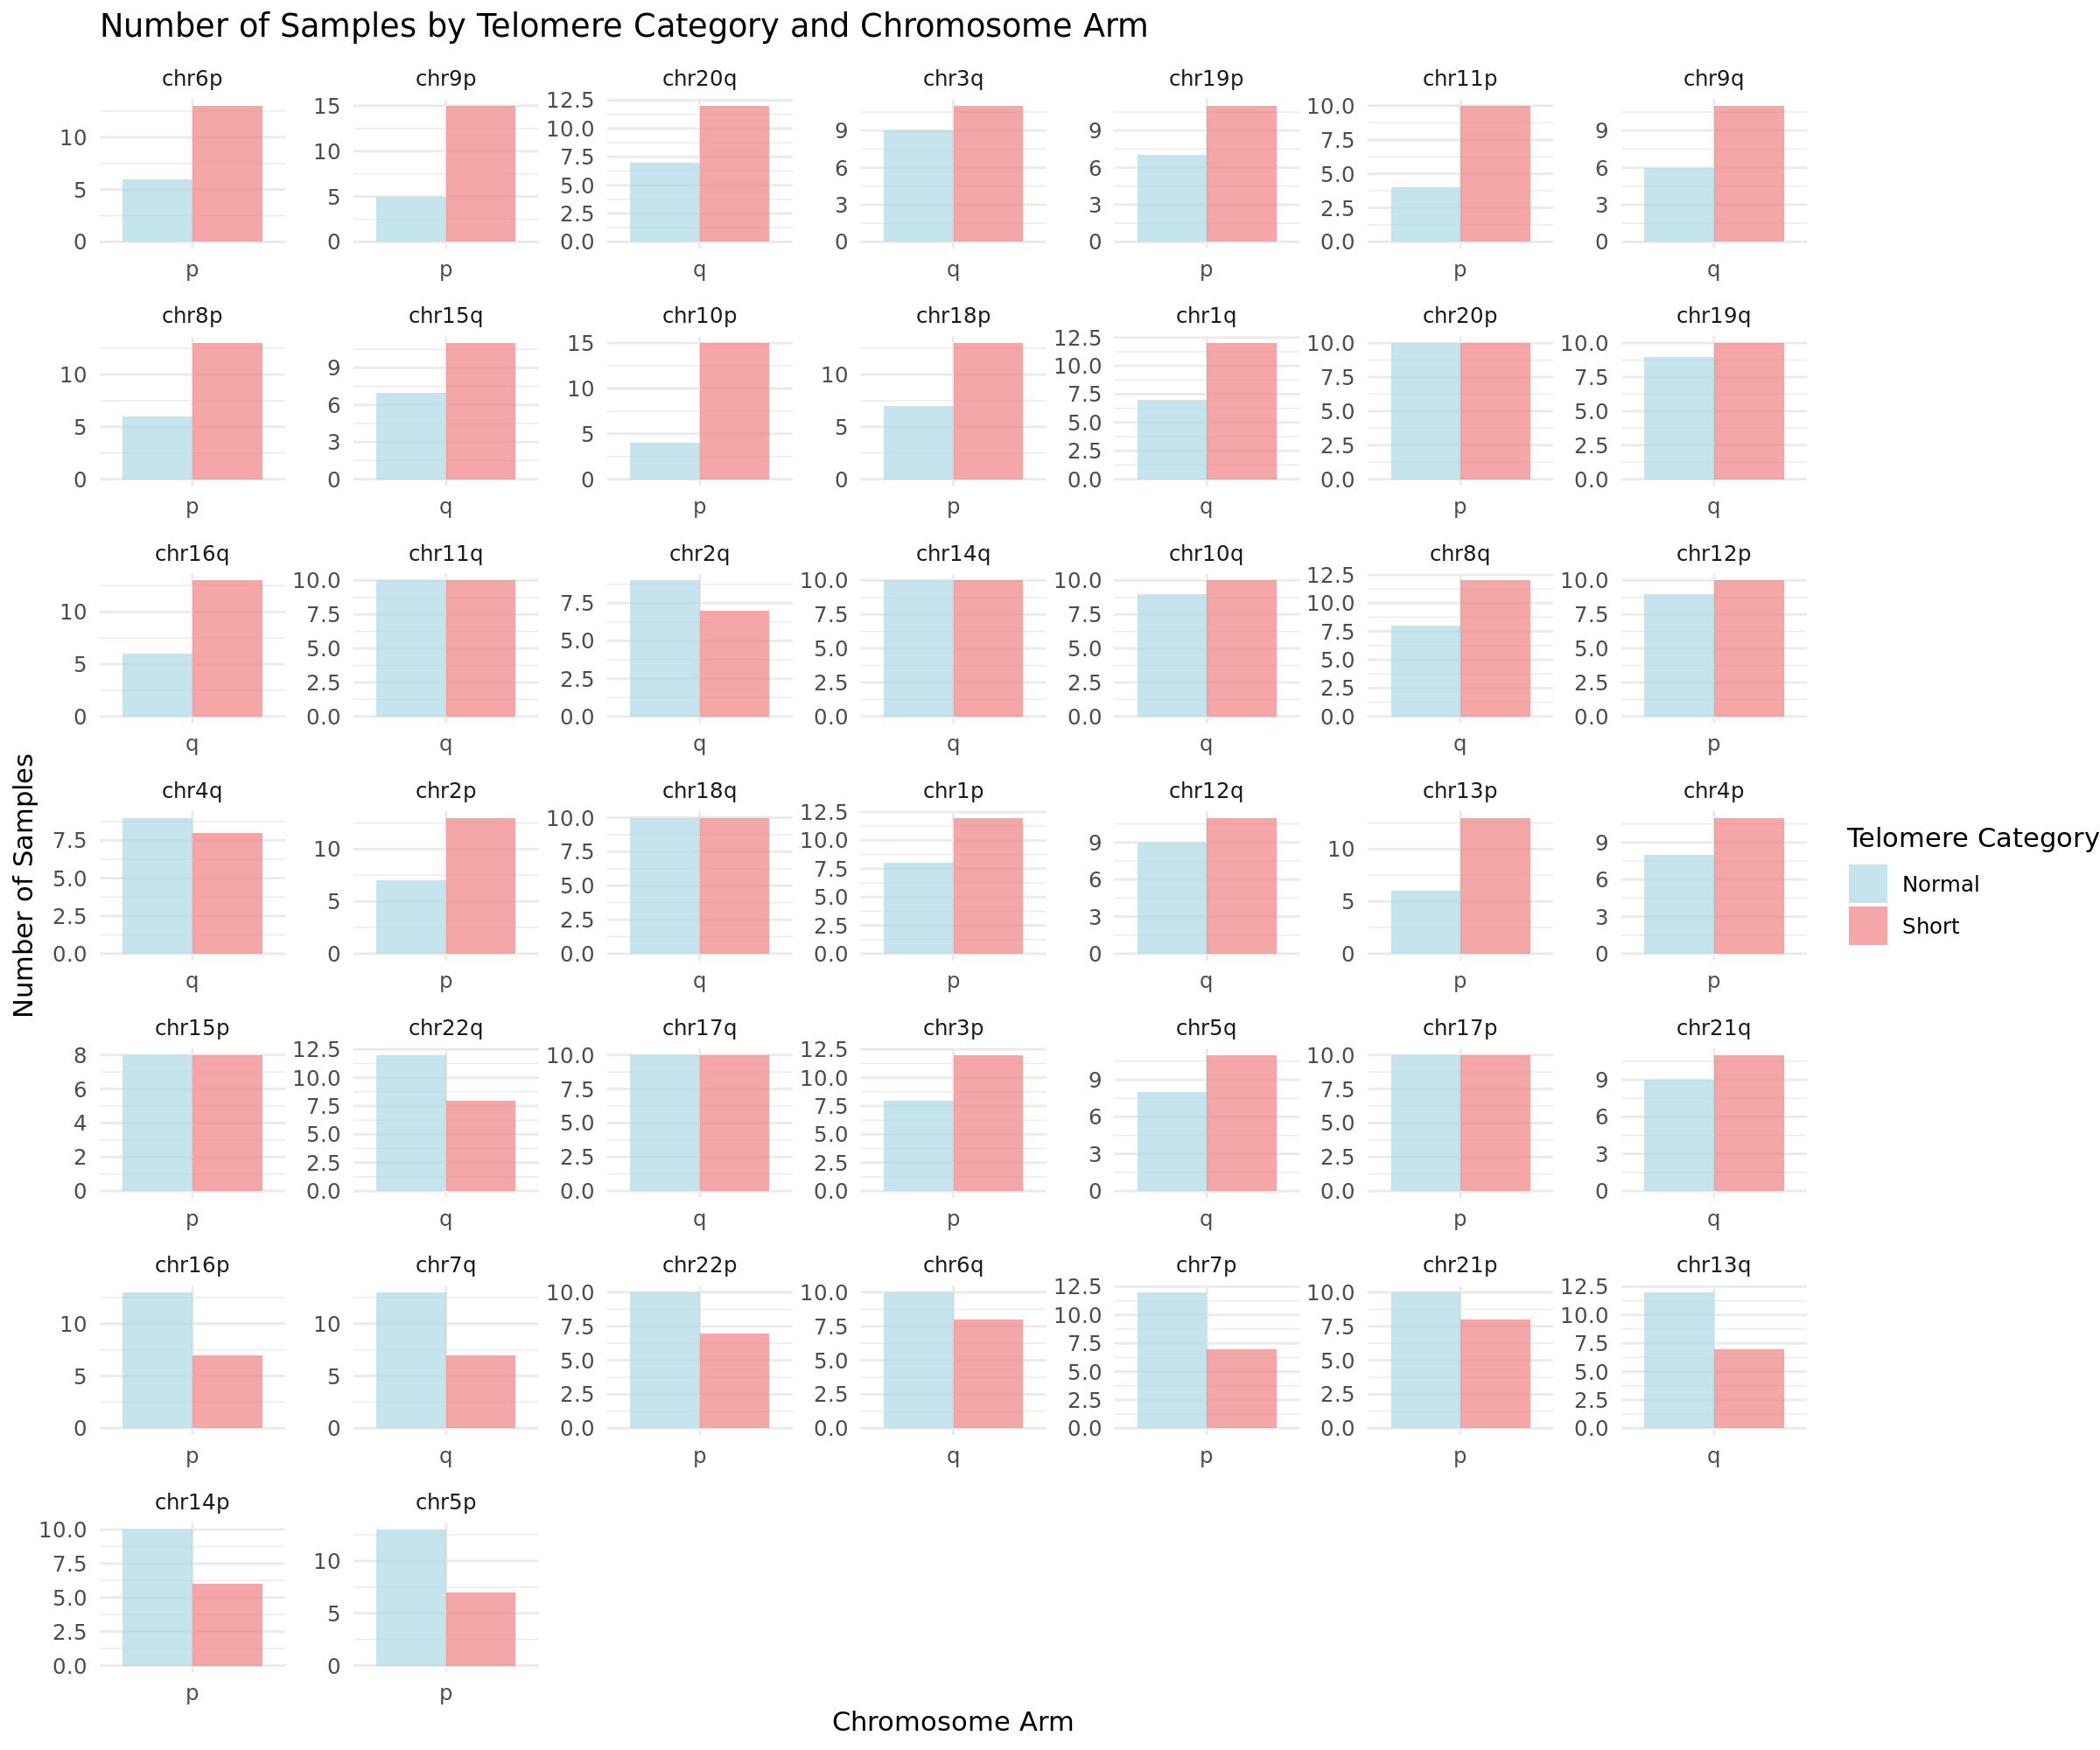

In [77]:
# Print the plot
options(repr.plot.width = 12, repr.plot.height = 10, repr.plot.res = 200)

print(p)


In [78]:
pdf(file = "p_arm_samples_comparison_normal_vs_short.pdf", width = 12, height = 6)
print(p)
dev.off()

pdf 
  2

In [79]:
head(data)

,Sample_prefix,chr,final_average_TL_p75,chr_order,arm,grand_mean_TL,relative_TL,Category
,<chr>,<fct>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<chr>
1,2436A,chr1p,5221.000,1,p,5536.658,-0.3156577,Normal
2,2436A,chr1q,5051.167,1,q,5536.658,-0.4854910,Normal
3,3188,chr1p,1642.500,1,p,2790.818,-1.1483177,Short
4,3188,chr1q,3086.500,1,q,2790.818,0.2956823,Short
5,3988,chr1p,2347.500,1,p,5630.677,-3.2831773,Short
6,3988,chr1q,5083.000,1,q,5630.677,-0.5476773,Normal


In [ ]:
#plot interesting chromosomes with telomere shorterning

In [80]:

# Specify the chromosomes to plot
chromosomes_to_show <- c("chr6p", "chr9p", "chr11p", "chr10p", "chr19p",  "chr8p")  # Replace with your desired chromosomes

# Filter the data for the specified chromosomes
data_filtered <- data %>%
  filter(chr %in% chromosomes_to_show) %>%
  mutate(final_average_TL_kb = final_average_TL_p75 / 1000)  # Convert to kb


In [81]:

# t-test for each chromosome to see if the difference in normal and short is significant
significant_chromosomes <- data_filtered %>%
  group_by(chr) %>%
  summarise(
    p_value = t.test(final_average_TL_kb ~ Category)$p.value
  ) %>%
  filter(p_value < 0.05) %>%
  arrange(p_value)  # Order by p-value (ascending)


In [105]:
p <- ggplot(data_filtered, aes(x = chr, y = final_average_TL_kb, fill = Category)) +
  geom_boxplot(outlier.shape = NA, width = 0.4, alpha = 0.5) +
  geom_jitter(
    aes(color = Category), 
    position = position_jitterdodge(dodge.width = 0.5, jitter.width = 0.12), 
    alpha = 0.9, size = 1.8
  ) +
  scale_fill_manual(values = c("Short" = "lightcoral", "Normal" = "lightblue")) +
  scale_color_manual(values = c("Short" = "lightcoral", "Normal" = "lightblue")) +
  stat_compare_means(aes(group = Category), method = "t.test", label = "p.signif") + #facet_wrap(~ chr, scales = "free", ncol = 1) +
  labs(
    title = "Telomere Length Comparison (Ordered by Significance)",
    x = "Chromosome Arms",
    y = "Telomere Length (kb)",
    fill = "Telomere Category",
    color = "Telomere Category"
  ) +
  theme_minimal()
#width = 0.5, alpha = 0.5, outlier.shape = NA, color = "black", position = position_dodge(width = 0.75)

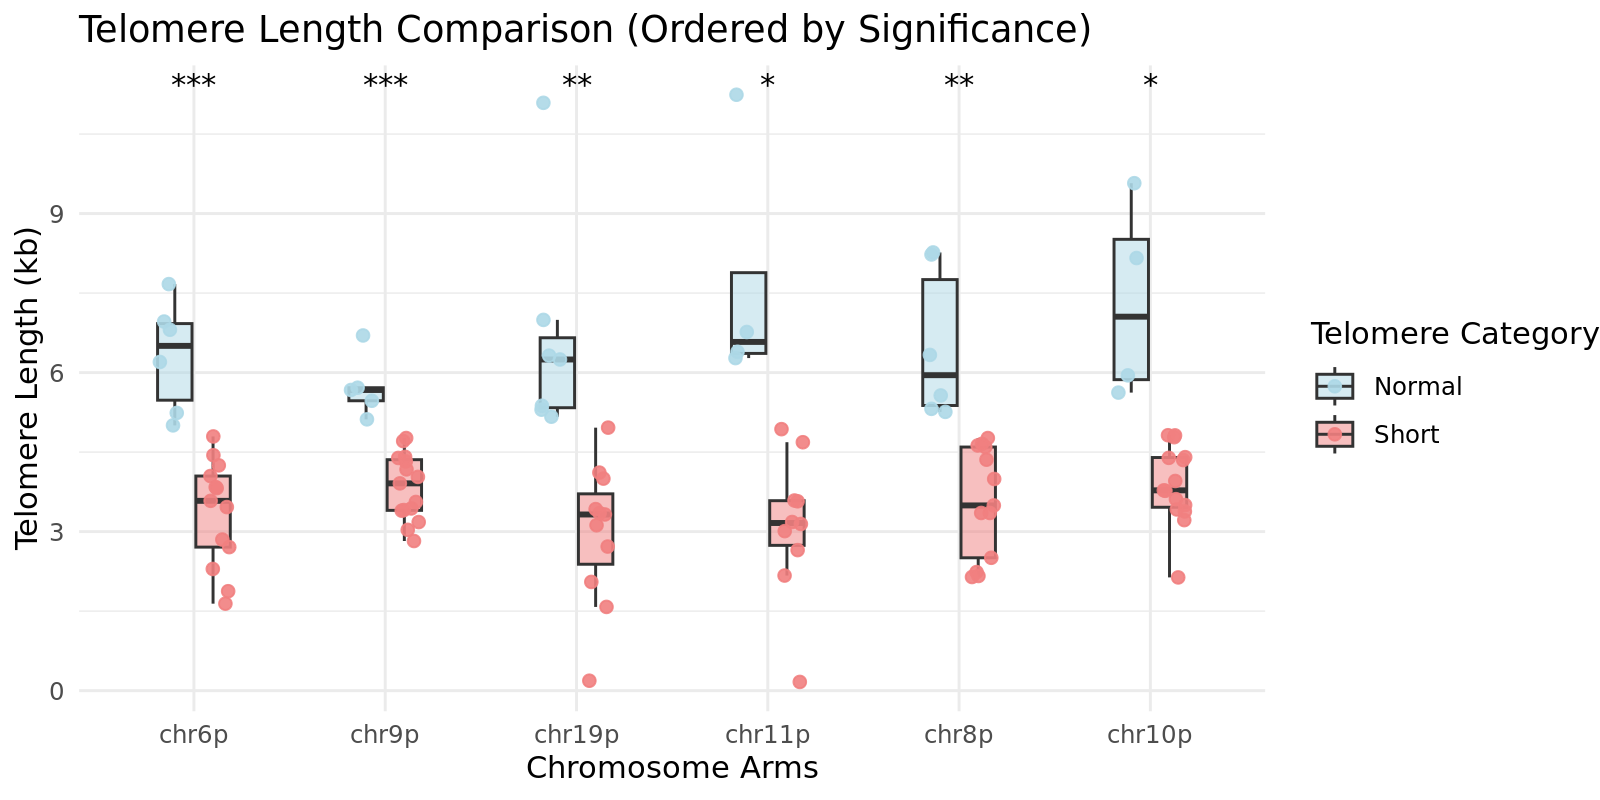

In [106]:
options(repr.plot.width = 8, repr.plot.height = 4, repr.plot.res = 200)
print(p)

In [107]:
pdf(file = "Short_vs_long_chromosomes_p_arm.pdf", width = 8, height = 4)
print(p)
dev.off()

pdf 
  2